In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\HP\AI-Learning\day-04\train.csv")

df.isnull().sum()



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\HP\AI-Learning\day-04\train.csv")

df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [20]:
df["Survived"].value_counts()

Survived
0    549
1    340
Name: count, dtype: int64

In [38]:
df['Survived'].mean() * 100

np.float64(38.38383838383838)

In [41]:
df.groupby('Sex')["Survived"].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [42]:
df.groupby('Sex')["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [47]:
df.groupby('Pclass')["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [54]:
df.groupby('Survived')['Age'].mean()


Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [65]:
df['Age'].min()

0.42

In [60]:
print(df['Age'].min())
print(df['Age'].max())


0.42
80.0


In [62]:
df[df['Age'] == 80.0]['Survived'].values

array([1])

In [67]:
df['Fare'].max()

512.3292

In [70]:
df[df['Fare']==df['Fare'].max()]['Survived'].values

array([1, 1, 1])

In [71]:
df.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

In [16]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [31]:
df['FamilySize']=df['SibSp']+df['Parch']+1
df.groupby('Survived')['FamilySize'].mean()


Survived
0    1.883424
1    1.938596
Name: FamilySize, dtype: float64

In [3]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
df=df.dropna(subset=['Embarked'])

In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

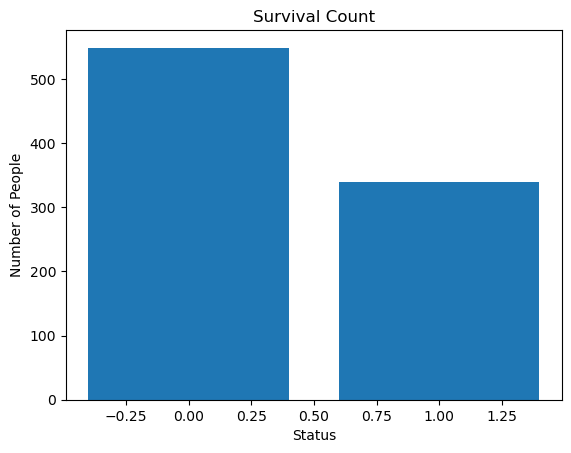

In [28]:
A = df['Survived'].value_counts()
plt.bar(A.index, A.values)
plt.title("Survival Count")
plt.xlabel("Status")
plt.ylabel("Number of People")
plt.show()

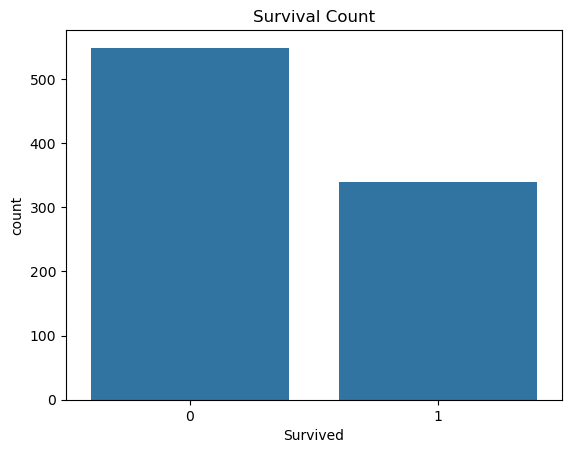

In [27]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

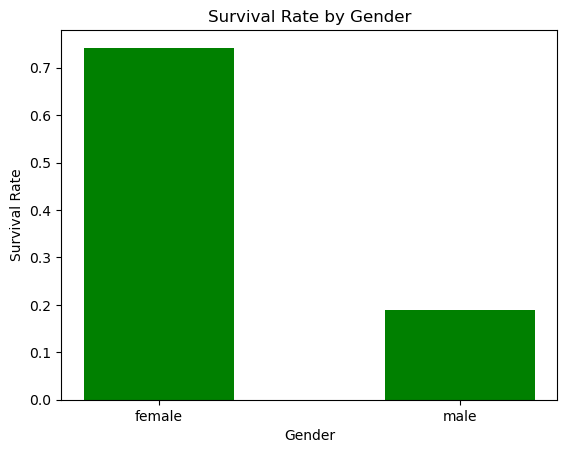

In [55]:
import matplotlib.pyplot as plt
A=df.groupby('Sex')['Survived'].mean()
plt.bar(A.index,A.values,color='Green',width=0.5)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

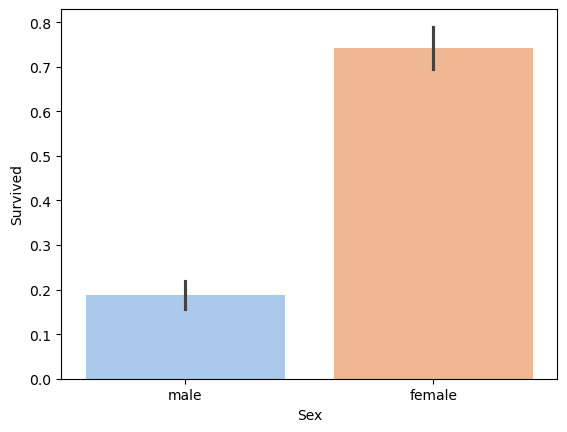

In [53]:
sns.barplot(x='Sex', y='Survived', hue='Sex', data=df, palette='pastel', legend=False)
plt.show()

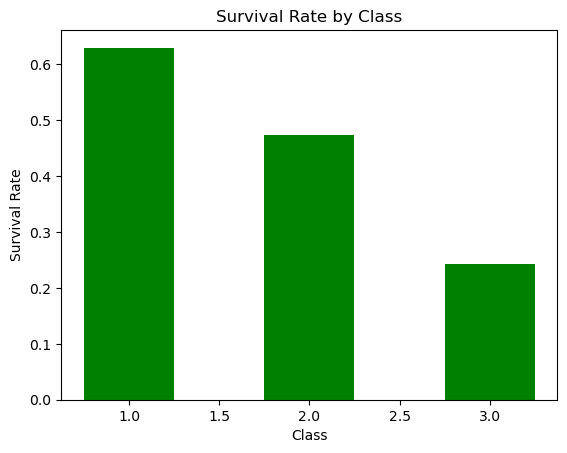

In [61]:
A = df.groupby('Pclass')['Survived'].mean()

plt.bar(A.index, A.values, color='green', width=0.5)
plt.title('Survival Rate by Class')
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.show()

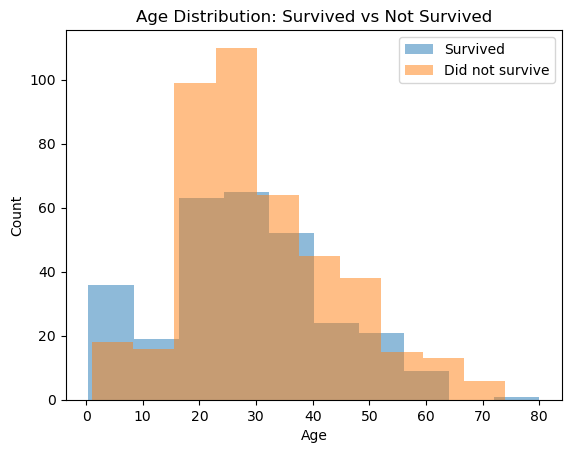

In [62]:
survived = df[df['Survived'] == 1]['Age']
not_survived = df[df['Survived'] == 0]['Age']
plt.hist(survived, alpha=0.5, label='Survived')
plt.hist(not_survived, alpha=0.5, label='Did not survive')
plt.title("Age Distribution: Survived vs Not Survived")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

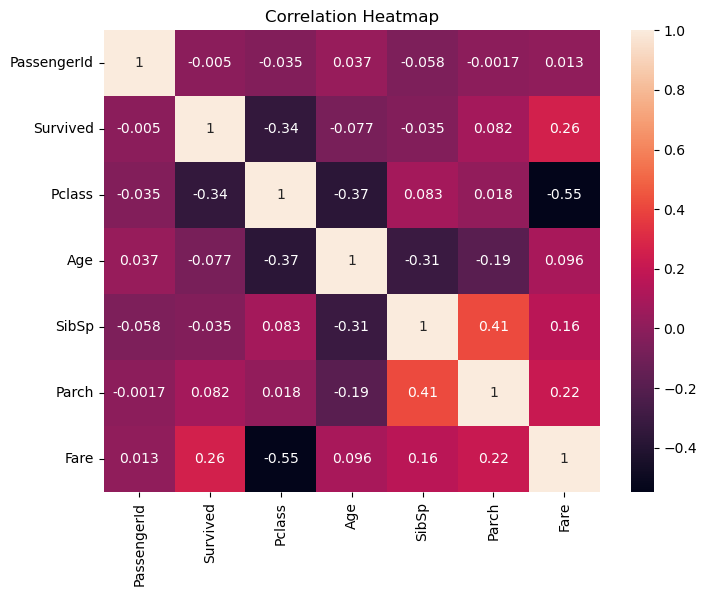

In [64]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

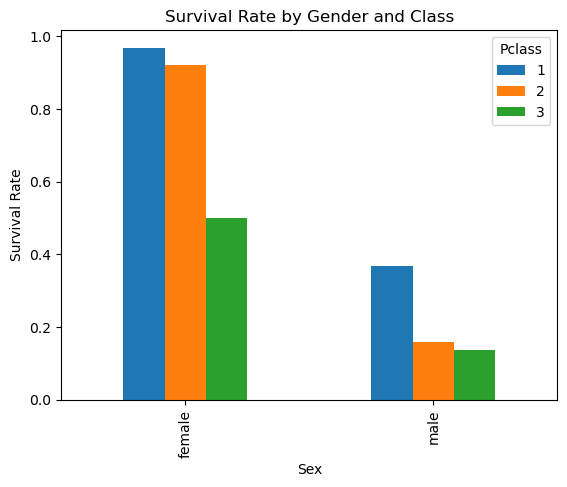

In [65]:
A = df.groupby(['Sex', 'Pclass'])['Survived'].mean()
A = A.unstack()
A.plot(kind='bar')
plt.title("Survival Rate by Gender and Class")
plt.ylabel("Survival Rate")
plt.show()